# 04 · SciPy 루틴 (cupyx.scipy.*)

> **CuPy 2일 집중 코스 — Day 1 / 단원 2 (NumPy/SciPy CuPy 프로그래밍)**

공식 [overview](https://docs.cupy.dev/en/stable/overview.html)의 **SciPy Routines** 를 본격적으로 — `scipy.*` → `cupyx.scipy.*` 치환으로.
FFT·선형대수·이미지 처리·**희소행렬**·희소 선형대수·신호처리를 미니앱과 함께 다룹니다.

### 왜 SciPy 루틴인가
`03_numpy_routines`에서 다룬 `cupy.*`가 NumPy의 배열 연산(사칙연산, 브로드캐스팅, 선형대수 기본)을
GPU로 옮기는 것이었다면, 이 노트북은 한 단계 더 나아가 **SciPy가 제공하는 전문 수치 알고리즘**
— FFT 기반 변환, 행렬 분해, 이미지 컨볼루션, 희소 선형계, 신호 필터 — 을 GPU로 옮깁니다. 실제
과학기술computing 워크로드(이미지 처리, 센서 신호, PDE 이산화 등)는 NumPy만으로 끝나지 않고
SciPy 서브패키지를 광범위하게 사용하므로, 이 매핑을 익히는 것은 NumPy 매핑 못지않게 중요합니다.

CuPy는 `scipy` 자체를 감싸는 것이 아니라, **`cupyx.scipy` 라는 독자적인 네임스페이스**에서 동일한
API를 재구현합니다(`cupyx`는 "CuPy 확장"이라는 뜻, `00_intro_env` 3.2절 참고). 내부적으로는 각
서브패키지가 서로 다른 NVIDIA 라이브러리를 백엔드로 사용합니다 — FFT/DCT는 **cuFFT**, LU분해·
행렬지수는 **cuSOLVER**, 희소행렬 연산은 **cuSPARSE**. 이 노트북 곳곳에서 "이 함수는 내부적으로
어떤 백엔드를 쓰는가"를 짚어가며 이해도를 높입니다.

### 이 노트북의 흐름
FFT/DCT(주파수 영역 압축) → 조밀 선형대수(LU/expm) → 이미지 컨볼루션·연결요소 → **희소행렬
내부구조** → 희소 선형대수(2D 푸아송) → 신호처리 필터 → 수치안정 특수함수. 앞의 세 절은 비교적
"익숙한" NumPy식 조밀 배열 연산의 연장이고, 4~5절의 **희소행렬**이 이 노트북의 핵심 — 메모리
절약과 SpMV 성능이 결합돼 GPU 가속 효과가 가장 극적으로 드러나는 영역입니다.

## 학습 목표
- `scipy.*` 코드를 `cupyx.scipy.*` 로 포팅하고 CPU와 정확성을 검증한다.
- 희소행렬 포맷·내부구조를 이해하고 2D 푸아송을 직접/반복법으로 푼다.
- 이미지 분석(`ndimage`)·신호 필터(`signal`)·수치 안정 함수(`special`)를 활용한다.


## 목차
1. [FFT `scipy.fft` + DCT 압축](#1)
2. [선형대수 `scipy.linalg`](#2)
3. [이미지 처리 `ndimage` + 연결요소](#3)
4. [희소행렬 `sparse` (+포맷·내부구조)](#4)
5. [희소 선형대수 `sparse.linalg` + 2D 푸아송](#5)
6. [신호처리 `signal`](#6)
7. [special · stats](#7)
8. [체크포인트](#8)

> 백엔드: cuFFT·cuSOLVER·cuSPARSE. 모두 `scipy`와 동일 인터페이스입니다. 함수 시그니처를 그대로
> 유지한 채 내부 계산만 GPU 라이브러리로 위임하므로, "포팅"은 대부분 `scipy` → `cupyx.scipy` 로
> import 경로만 바꾸는 작업이 됩니다 — 단, `00_intro_env` 3.1절에서 짚었듯 정밀도·엣지케이스
> 차이는 각 절에서 `allclose`로 직접 확인합니다.


In [1]:
import os, sys, time, math
import numpy as np
import cupy as cp
from course_utils import print_env, bench, cpu_ms, gpu_ms, compare, allclose
print_env()

=== Environment ===
numpy: 2.3.5
cupy : 14.1.1
device: 0 - NVIDIA A100-SXM4-80GB (compute capability 8.0)
VRAM  : 79.25 GB


<a id="1"></a>
## 1. FFT `scipy.fft` + DCT 압축

📖 [`cupyx.scipy.fft`](https://docs.cupy.dev/en/stable/reference/scipy_fft.html) — `fft`, `rfft`, `dct/idct`, `dst`, `next_fast_len`

FFT 계열 함수는 모두 **cuFFT**가 구동합니다. cuFFT는 NVIDIA가 제공하는 고도로 최적화된 FFT
라이브러리로, 입력 길이가 2, 3, 5, 7의 거듭제곱(과 그 곱)으로 이루어진 "fast length"일 때 가장
빠릅니다 — 임의 길이도 동작은 하지만, 소인수가 큰 경우 내부적으로 느린 경로를 타 성능이 떨어질
수 있습니다. 아래 `next_fast_len`으로 이를 미리 확인하는 습관을 들이면 좋습니다.


### 🔬 이론 배경 — DCT
- **DCT**(이산 코사인 변환): 실수 코사인 기저로 변환. 신호 에너지를 **소수의 저주파 계수**에 집중시킴.
  → 상위 계수만 남기면 **손실 압축**(JPEG·MP3의 핵심 원리).
- 우리가 보는 사진이나 듣는 음악 데이터에는 인간의 눈과 귀가 눈치채지 못하는 고주파 잡음이 너무 많음.
- DCT(이산 코사인 변환) 변환을 하면 데이터가 '주파수 세상'으로 변하면서, 가장 중요한 굵직한 정보(저주파 성분)들은 앞쪽에 몰리고, 사람이 들을 수 없는 고주파 성분 들은 뒤쪽으로 밀려남.
  → 손실 압축: 뒤쪽으로 밀려난 쓸모없는 숫자들을 0으로 싹 날려버릴 수 있음. 이것이 바로 화질이나 음질을 살짝 희생하면서 용량을 줄이는 손실 압축의 원리임.

### 조금 더 구체적으로

DCT-II(가장 흔히 쓰이는 형태)의 정의는 다음과 같습니다.

$$X_k = \sum_{n=0}^{N-1} x_n \cos\!\left[\frac{\pi}{N}\left(n+\frac12\right)k\right], \quad k=0,\dots,N-1$$

FFT와 달리 **실수 입력 → 실수 출력**이라 복소수 연산·저장 오버헤드가 없고, 경계에서 신호가
매끄럽게 이어진다고 "가정"하는 코사인 기저 특성 덕분에 자연 신호(음성·이미지)에서 **DFT보다
에너지가 더 소수의 계수에 집중**됩니다 — 이것이 JPEG가 FFT가 아닌 DCT를 채택한 이유입니다.
JPEG는 실제로 8×8 블록 단위 2D DCT를 수행한 뒤 사람 눈이 둔감한 고주파 계수를 **양자화
테이블**로 거칠게 반올림(사실상 0에 가깝게)해 압축합니다 — 아래 미니앱의 `X[keep:] = 0`은 그
과정을 극단적으로 단순화한 버전입니다.

내부적으로 SciPy/CuPy의 DCT는 FFT 알고리즘을 재활용해 구현되므로(길이를 늘린 뒤 FFT를 태우는
방식 등), 백엔드는 여전히 **cuFFT**입니다. 따라서 위 절에서 언급한 "fast length"(2·3·5·7의 곱)
조건이 DCT 성능에도 그대로 적용됩니다.


In [2]:
from scipy.fft import dct as sp_dct, idct as sp_idct
from cupyx.scipy.fft import dct as cp_dct, idct as cp_idct, next_fast_len
x_np = np.random.random(100_000).astype(np.float32); x_cp = cp.asarray(x_np)

# "CPU가 한 압축 결과와 GPU가 한 압축 결과가 똑같은지" 검증하는 코드
# norm='ortho'는 변환 전후의 데이터 총 에너지를 보존하라는 수학적 옵션
allclose(sp_dct(x_np, norm='ortho'), cp_dct(x_cp, norm='ortho'), rtol=1e-3, atol=1e-3, name='DCT')
compare('DCT', lambda: sp_dct(x_np, norm='ortho'), lambda: cp_dct(x_cp, norm='ortho'), n_repeat=3, n_warmup=1)
compare('DCT', lambda: sp_dct(x_np, norm='ortho'), lambda: cp_dct(x_cp, norm='ortho'), n_repeat=3, n_warmup=1)

# next_fast_len(100_000)은 "지금 데이터가 100,000개인데, 연산 속도를 극대화하려면 데이터를 몇 개로 맞춰주는 게 좋아?"라고 물어보는 함수.
print('next_fast_len(100000)=', next_fast_len(100_000))

[allclose OK] DCT
next_fast_len(100000)= 100000


### 미니앱 — DCT 기반 압축
DCT 계수의 **상위 일부만 유지**하고 역변환하면 손실 압축이 됩니다. 유지 비율에 따른 복원 오차를 보세요.

### 조금 더 구체적으로

테스트 신호는 저주파 성분(3 Hz 사인)과 고주파 성분(40 Hz 사인, 진폭 0.3배)을 섞은 것으로, DCT가
"중요한 저주파는 앞에, 덜 중요한 고주파는 뒤에" 배치한다는 사실을 직접 확인하기 위한 합성
신호입니다. `keep` 값은 곧 **압축률**과 직결됩니다 — 원본은 4096개 계수인데 `keep=64`만 남기면
압축률은 약 `64/4096 ≈ 1.6%`(64배 압축)입니다. `keep`이 커질수록(256 → 6.25%, 1024 → 25%) 복원
오차(`‖복원 − 원본‖ / ‖원본‖`)가 줄어드는 것을 수치로 확인할 수 있습니다. 실제로 `keep=64` 정도만
되어도 3 Hz 저주파 성분은 거의 완벽히 복원되고, 40 Hz 고주파 성분(잡음에 가까운 디테일)만 사라지는
것을 다음 시각화 셀의 4단 그래프에서 눈으로 볼 수 있습니다.


In [3]:
def dct_compress(x, keep):
    xp = cp.get_array_module(x)
    dct = cp_dct if xp is cp else sp_dct
    idct = cp_idct if xp is cp else sp_idct
    # keep개만 남기고 나머지는 0으로 날려버리는 압축
    X = dct(x, norm='ortho'); X[keep:] = 0
    return idct(X, norm='ortho')

t = np.linspace(0,1,4096,endpoint=False).astype(np.float32)
sig = (np.sin(2*np.pi*3*t)+0.3*np.sin(2*np.pi*40*t)).astype(np.float32)
for keep in [64, 256, 1024]:
    r = dct_compress(cp.asarray(sig), keep)
    err = float(cp.linalg.norm(r-cp.asarray(sig))/cp.linalg.norm(cp.asarray(sig)))
    print(f'keep={keep:>5}  상대오차={err:.3e}')
compare('dct_compress', lambda: dct_compress(sig, 256), 
                        lambda: dct_compress(cp.asarray(sig), 256), n_repeat=3, n_warmup=1)

keep=   64  상대오차=2.849e-01
keep=  256  상대오차=3.813e-03
keep= 1024  상대오차=4.220e-04


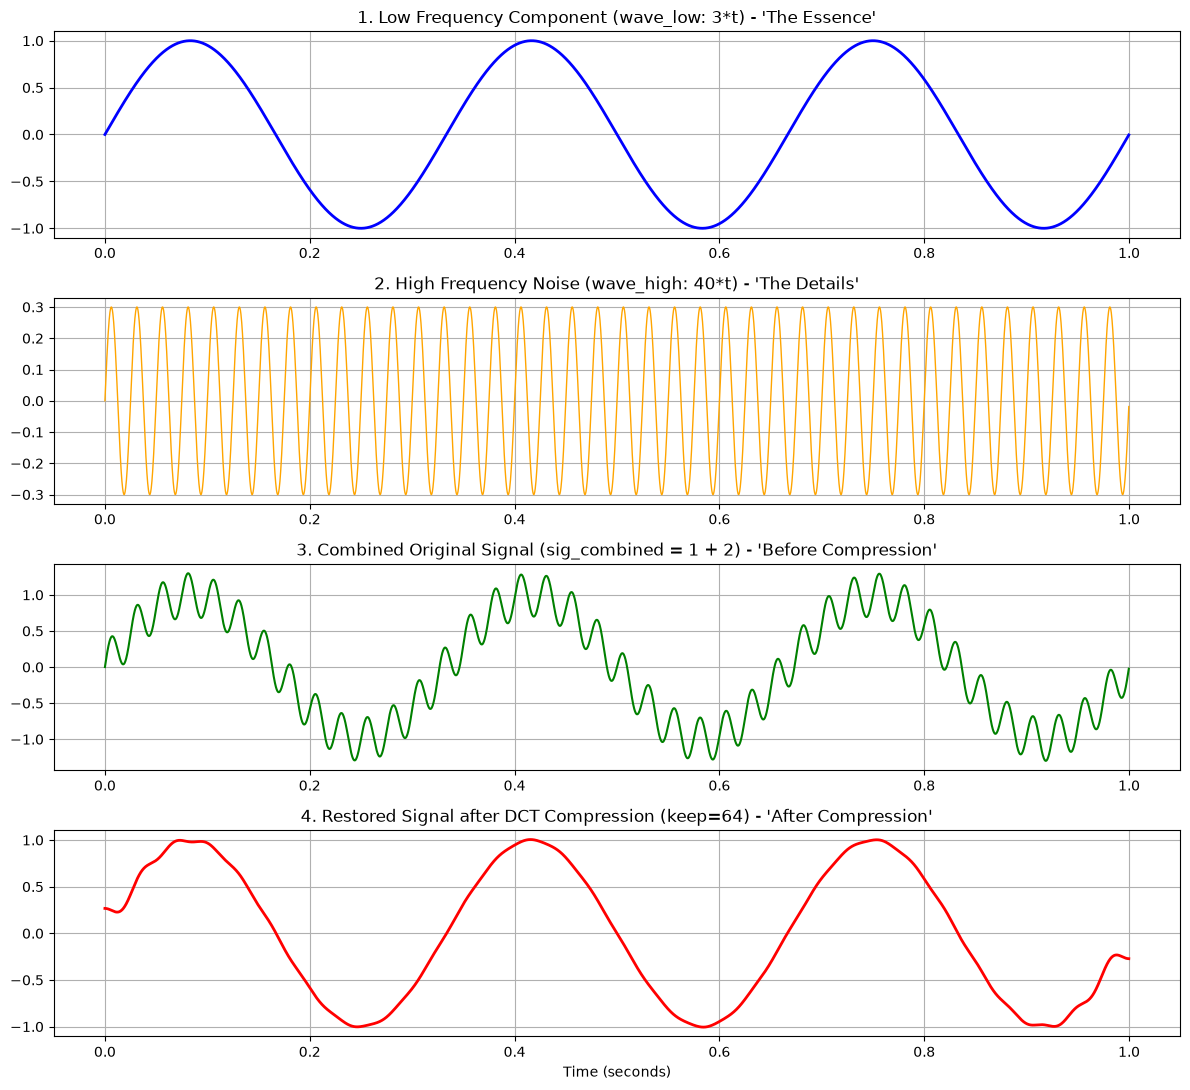

In [4]:
# 추가 - 파형 확인
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dct as sp_dct, idct as sp_idct

# 2. 데이터 및 각 신호 준비
t = np.linspace(0, 1, 4096, endpoint=False)
wave_low = np.sin(2 * np.pi * 3 * t)          # ① 완만한 파도
wave_high = 0.3 * np.sin(2 * np.pi * 40 * t)  # ② 자글자글한 잔물결
sig_combined = (wave_low + wave_high).astype(np.float32)  # ③ 둘이 합쳐진 원본

# ④ keep=64 옵션을 거친 압축 복원 신호
sig_compressed = dct_compress(sig_combined, keep=64)

# 3. 4단 세로 그래프 그리기
plt.figure(figsize=(12, 11))

# ① 첫 번째: 완만한 파도 (3Hz)
plt.subplot(4, 1, 1)
plt.plot(t, wave_low, color='blue', linewidth=2)
plt.title("1. Low Frequency Component (wave_low: 3*t) - 'The Essence'")
plt.grid(True)

# ② 두 번째: 자글자글한 잔물결 (40Hz)
plt.subplot(4, 1, 2)
plt.plot(t, wave_high, color='orange', linewidth=1)
plt.title("2. High Frequency Noise (wave_high: 40*t) - 'The Details'")
plt.grid(True)

# ③ 세 번째: 둘이 합쳐진 실제 원본 데이터
plt.subplot(4, 1, 3)
plt.plot(t, sig_combined, color='green', linewidth=1.5)
plt.title("3. Combined Original Signal (sig_combined = 1 + 2) - 'Before Compression'")
plt.grid(True)

# ④ 네 번째: keep=64로 압축 후 복원한 결과
plt.subplot(4, 1, 4)
plt.plot(t, sig_compressed, color='red', linewidth=2)
plt.title("4. Restored Signal after DCT Compression (keep=64) - 'After Compression'")
plt.xlabel("Time (seconds)")
plt.grid(True)

# 레이아웃 깔끔하게 다듬고 화면 출력
plt.tight_layout()
plt.show()

<a id="2"></a>
## 2. 선형대수 `scipy.linalg`

📖 [`cupyx.scipy.linalg`](https://docs.cupy.dev/en/stable/reference/scipy_linalg.html) — `lu_factor/lu_solve`, `solve_triangular`, `expm`, `toeplitz` 등

### 예제 설명
- 1200개의 미지수를 가진 거대한 연립방정식을 푸는 코드
- 우리가 풀어야 할 연립방정식은 Ax = b. 행렬 A라는 문제집이 있고, b라는 정답지가 있을 때, 미지수 x를 구하는 것.
- 컴퓨터는 이 문제를 풀 때 A를 하삼각행렬(L)과 상삼각행렬(U)이라는 풀기 쉬운 두 개의 행렬로 쪼개는데, 이를 LU 분해라고 합니다.
- lu_factor: 복잡한 행렬 A를 연산하기 쉬운 형태(lu, piv)로 쪼개고 변형하는 단계. (전체 연산량의 99%를 차지할 만큼 무겁습니다.)
- lu_solve: 쪼개놓은 뼈대를 가지고 실제 정답(b)을 대입해서 해(x)를 구해내는 단계. (엄청나게 가볍고 빠릅니다.)

### 조금 더 구체적으로

- **연산량 비대칭**: `n×n` 밀집행렬의 LU 분해는 약 `(2/3)n³` FLOPs가 필요한 반면, 분해가 끝난 뒤
  `lu_solve`(전진대입 + 후진대입)는 `O(n²)`에 불과합니다. `n=1200`이면 분해는 `n³ ≈ 1.7×10⁹`
  스케일, 풀이는 `n² ≈ 1.4×10⁶` 스케일로 **약 1000배 차이**가 납니다 — 그래서 코드 주석처럼
  "분해가 전체 연산량의 99% 이상"이라는 말이 나옵니다. 같은 행렬 A에 대해 b만 바뀌는 문제를
  여러 번 풀어야 한다면(예: 시간에 따라 변하는 우변으로 반복 계산하는 시뮬레이션), `lu_factor`를
  **한 번만** 하고 `lu_solve`를 재사용하는 것이 핵심 최적화입니다.
- **백엔드**: `lu_factor`/`lu_solve`/`expm` 모두 **cuSOLVER**가 구동합니다. cuSOLVER는 cuBLAS
  위에 구축된 조밀 선형대수 라이브러리로, LAPACK과 유사한 함수 구성을 GPU에 최적화해 제공합니다.
- **정부호화(regularization) 트릭**: 코드의 `A = ... + n*cp.eye(n)`처럼 대각에 큰 값을 더해
  **대각 우세(diagonally dominant)** 행렬로 만드는 기법은 임의의 무작위 행렬을 수치적으로
  안정하게 분해 가능한 행렬로 바꾸는 실습용 트릭입니다. 실제 응용(예: 5절의 2D 라플라시안)에서는
  물리적으로 이미 양의 정부호인 행렬이 자연스럽게 나오는 경우가 많습니다.


In [5]:
from cupyx.scipy.linalg import lu_factor as cp_lu_factor, lu_solve as cp_lu_solve
from scipy.linalg import lu_factor as np_lu_factor, lu_solve as np_lu_solve

n=500
# n * cp.eye(...)는 대각선 자리에 큰 숫자(1200)를 더해주는 작업. 행렬 A가 **양의 정부호**(positive definite) 행렬이 되도록 만들어서, 연립방정식 Ax=b를 풀 때 안정적으로 풀리도록 보장하는 역할.
A = cp.random.random((n,n),dtype=cp.float32) + n*cp.eye(n,dtype=cp.float32)
b = cp.random.random(n,dtype=cp.float32)
lu,piv = cp_lu_factor(A); x = cp_lu_solve((lu,piv), b)
allclose(A@x, b, rtol=1e-3, atol=1e-3, name='lu_solve')

A_np = np.random.random((n,n),dtype=np.float32) + n*np.eye(n,dtype=np.float32)
b_np = np.random.random(n,dtype=np.float32)
lu_np,piv_np = np_lu_factor(A_np); x_np = np_lu_solve((lu_np,piv_np), b_np)
compare('lu_solve', lambda: cp_lu_solve((lu,piv), b), lambda: np_lu_solve((lu_np,piv_np), b_np), n_repeat=3, n_warmup=1)

[allclose OK] lu_solve


**연습 — 행렬지수 `expm`**: `scipy.linalg.expm` 코드를 GPU로 포팅하고 CPU와 비교하세요.

`expm(M)`은 테일러 급수 `I + M + M²/2! + ...`를 그대로 계산하지 않고, 수치적으로 안정한
**scaling-and-squaring + Padé 근사** 알고리즘을 사용합니다(행렬을 2의 거듭제곱으로 나눠 작게
만든 뒤 Padé 근사로 지수를 구하고, 다시 제곱해서 복원). 이 알고리즘은 여러 번의 조밀 행렬곱과
LU 계열 분해를 반복하므로, 위 2절에서 다룬 cuSOLVER 기반 연산이 내부에서 반복 호출됩니다.
행렬지수는 선형 ODE(`dx/dt = Mx`)의 해가 `x(t) = expm(Mt) x(0)`로 주어지는 등, 동역학 시스템
시뮬레이션에서 자주 등장합니다.


In [6]:
from scipy.linalg import expm as sp_expm
from cupyx.scipy.linalg import expm as cp_expm
M_np = (0.1*np.random.randn(64,64)).astype(np.float32)
# TODO
# allclose(..., ..., rtol=1e-2, atol=1e-2, name='expm')
# compare('expm', lambda: cp_expm(M_cp), lambda: sp_expm(M_np), n_repeat=3, n_warmup=1)

<details><summary>💡 해답 보기</summary>

```python
allclose(sp_expm(M_np), cp.asnumpy(cp_expm(cp.asarray(M_np))), rtol=1e-2, atol=1e-2, name='expm')
```

포인트: `rtol=atol=1e-2`처럼 다른 절보다 허용오차를 넉넉히 잡은 이유는, `expm`이 내부적으로
scaling-and-squaring 과정에서 여러 차례 행렬곱을 누적하기 때문입니다 — 각 곱셈마다 CPU와 GPU의
부동소수점 연산 순서가 미세하게 달라질 수 있고(`00_intro_env`의 "정확성 검증" 규칙 참고), 이
차이가 누적되면 단순 원소별 연산보다 오차가 커집니다.
</details>

<a id="3"></a>
## 3. 이미지 처리 `ndimage` + 연결요소

📖 [`cupyx.scipy.ndimage`](https://docs.cupy.dev/en/stable/reference/scipy_ndimage.html) — `gaussian_filter`, `sobel`, `label`, `center_of_mass`, `rotate`, `zoom`

`ndimage`는 N차원 배열(주로 이미지)에 대한 **컨볼루션 기반 필터**와 **형태학적 연산**을
제공합니다. GPU에서는 각 출력 픽셀이 독립적으로 계산 가능한 필터(가우시안, 소벨 등)는 스레드
단위로 완벽히 병렬화되지만, 뒤에서 다룰 `label`(연결요소 라벨링)처럼 **전역 연결성 정보**가
필요한 연산은 병렬화가 까다로워 별도의 GPU 전용 알고리즘(유니온-파인드의 병렬 변형)이 쓰입니다.


### 🔬 이론 배경 — 컨볼루션 필터
- 작은 **커널**을 이미지 위로 슬라이딩하며 이웃 픽셀의 **가중합**(컨볼루션).
- **가우시안** = 평활(잡음 제거), **소벨** = 공간 미분(엣지 검출).
- **`label`** = 연결요소(서로 인접한 전경 픽셀 그룹) 식별.

#### 예제 설명
컴퓨터에게 노이즈(잡음)가 잔뜩 낀 사진을 주면, 물체와 잡음을 구별하지 못해 엉뚱한 개수를 세게 됩니다. 그래서 코드 속 count_blobs 함수는 다음과 같은 3단계를 거칩니다.
1. gaussian_filter (가우시안 필터 - 블러 효과):
사진에 자글자글하게 낀 모래 같은 잡음(노이즈)을 부드럽게 뭉개버리는 단계입니다. 포토샵의 블러(Blur) 효과와 같습니다. 뭉개고 나면 진짜 중요한 굵직한 물체들만 선명하게 남습니다.
2. mask = g > 0.5 (이진화 - 흑백 나누기):
흐릿해진 사진에서 확실하게 밝은 부분(0.5보다 큰 부분)은 흰색(물체)으로, 어두운 부분은 검은색(배경)으로 구분합니다.
3. label (연결요소 식별 - 번호표 붙이기):
흰색 픽셀들이 서로 상하좌우로 붙어있는 것끼리 묶어서 1번 덩어리, 2번 덩어리... 하고 번호표를 붙여줍니다. 섬이 몇 개인지 지도에서 세어주는 것과 같습니다.

### 조금 더 구체적으로

- **컨볼루션의 계산량**: `k×k` 커널을 `H×W` 이미지에 적용하면 대략 `H·W·k²`번의 곱셈-누적이
  필요합니다. 가우시안 필터는 **분리 가능(separable)** 하다는 성질이 있어 — 2D 가우시안 커널을
  가로 1D 커널과 세로 1D 커널의 순차 적용으로 쪼갤 수 있음 — 실제 구현은 `O(H·W·k²)`가 아니라
  `O(H·W·k)`로 훨씬 저렴합니다. 소벨 커널(3×3)도 분리 가능해 더 가볍게 계산됩니다.
- **연결요소 라벨링이 어려운 이유**: 가우시안·소벨 같은 필터는 각 출력 픽셀이 **입력의 국소
  영역만 보고 독립적으로** 계산되므로 GPU 스레드 하나당 픽셀 하나를 맡기면 그대로 병렬화됩니다.
  반면 `label`은 "이 픽셀이 저 멀리 있는 픽셀과 같은 덩어리인지"를 판단해야 하는 **전역(global)
  문제**라 단순 병렬화가 안 됩니다. CuPy의 `ndimage.label`은 내부적으로 병렬 유니온-파인드
  (union-find)류 알고리즘으로 이를 해결하며, CPU의 순차 flood-fill과 결과(라벨 번호 자체)는
  다를 수 있어도 **덩어리 개수**는 항상 같습니다 — 그래서 미니앱은 라벨 배열이 아니라 개수(`num`)만
  비교합니다.


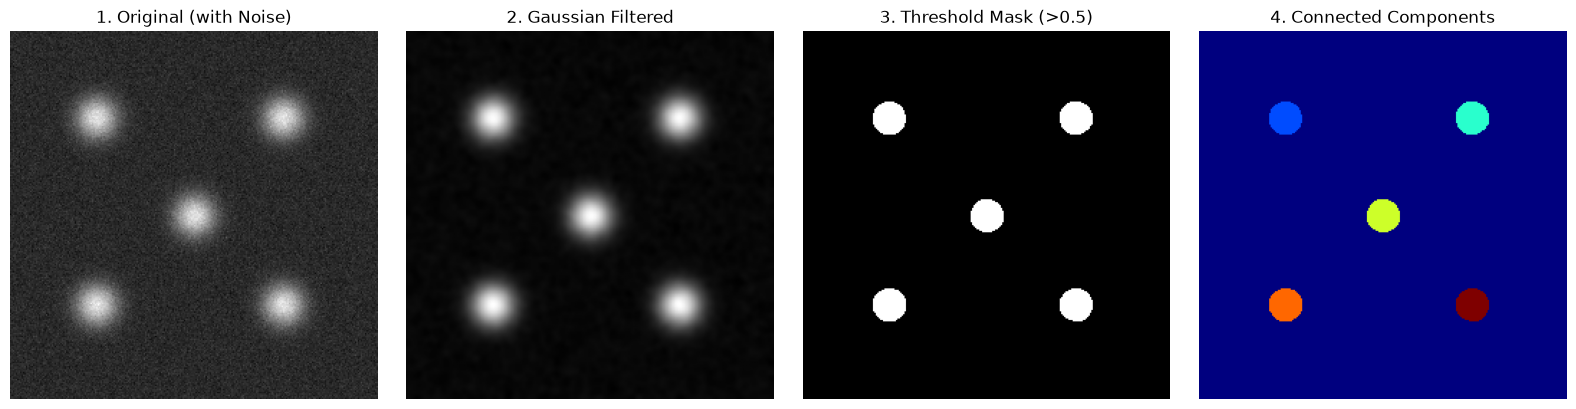

In [7]:
import scipy.ndimage as spnd
import cupyx.scipy.ndimage as cpnd
# 합성 이미지: 밝은 원반 5개 + 잡음
rng=np.random.default_rng(0); H=W=256
img=np.zeros((H,W),np.float32)
centers=[(60,60),(60,190),(190,60),(190,190),(128,128)]
yy,xx=np.mgrid[0:H,0:W]
for cy,cx in centers: img += np.exp(-(((yy-cy)**2+(xx-cx)**2)/200.0)).astype(np.float32)
img += 0.05*rng.standard_normal((H,W)).astype(np.float32)

def count_blobs_sp(image):
    g = spnd.gaussian_filter(image, sigma=2)
    mask = g > 0.5
    lab, num = spnd.label(mask)
    return num

def count_blobs(image, ndi):
    # TODO: 모듈 선택(ndi) -> gaussian_filter(sigma=2) -> mask(>0.5) -> label() -> return number of labels
    raise NotImplementedError
# print('연결요소 CPU:', count_blobs(img, spnd), '| GPU:', count_blobs(cp.asarray(img), cpnd))
# compare('count_blobs', lambda: count_blobs(img, spnd), lambda: count_blobs(cp.asarray(img), cpnd), n_repeat=3, n_warmup=1)

# ================= [시각화 출력 코드만 아래에 추가] =================
# 시각화를 위해 추가
# 그림 출력을 위해 함수 내부에서 일어나는 중간 과정 데이터를 똑같이 가져옵니다.

import matplotlib.pyplot as plt
g_img = spnd.gaussian_filter(img, sigma=2)  # 1. 가우시안 필터 처리된 이미지
mask_img = g_img > 0.5                      # 2. 이진화 마스크 이미지
lab_img, _ = spnd.label(mask_img)           # 3. 라벨링(번호표) 이미지

# 4칸짜리 가로로 긴 모니터를 만들어 단계별 변화를 봅니다.
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title("1. Original (with Noise)")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(g_img, cmap='gray')
plt.title("2. Gaussian Filtered")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(mask_img, cmap='gray')
plt.title("3. Threshold Mask (>0.5)")
plt.axis('off')

plt.subplot(1, 4, 4)
# 'jet' 색상 맵을 쓰면 컴퓨터가 각자 다르게 묶은 덩어리들이 알록달록하게 구별되어 보입니다.
plt.imshow(lab_img, cmap='jet')
plt.title("4. Connected Components")
plt.axis('off')

plt.tight_layout()
plt.show()

<details><summary>💡 해답 보기</summary>

```python
def count_blobs(image, ndi):
    g = ndi.gaussian_filter(image, sigma=2)
    mask = g > 0.5
    lab, num = ndi.label(mask)
    return num
```

포인트: `ndi` 인자 하나로 `spnd`(CPU)/`cpnd`(GPU) 모듈을 갈아끼우는 패턴은 이 노트북 전체에서
반복됩니다 — `cupy.get_array_module`(00·02 노트북)과 같은 발상으로, "같은 코드, 다른 백엔드"를
함수 인자화해 CPU/GPU 분기를 명시적으로 만듭니다. 라벨 개수(`num`)는 두 백엔드에서 항상 같아야
하지만, 개별 라벨 번호의 대응 관계(어느 덩어리가 1번인지)까지 같으리라는 보장은 없습니다.
</details>

**연습 — 그래디언트 크기**: 블러 후 `sobel`로 x·y 그래디언트 크기를 구하는 장치 비종속 함수를 완성하세요.

이 코드는 컴퓨터가 사진 속에서 "물체의 테두리(경계선/엣지)를 아주 선명하게 따내는 기술"입니다.
포토샵의 '선 따기' 필터나 웹툰 스타일의 필터, 혹은 자율주행차가 도로의 차선을 인식할 때 쓰는 핵심 알고리즘입니다.

* 컴퓨터는 어떻게 선을 딸까?
1. gaussian_filter (가우시안 필터):
  선을 따기 전에 자글자글한 잡음이 있으면 잡음까지 전부 선으로 따버리는 참사가 일어납니다. 그래서 먼저 사진을 부드럽게 뭉개서 잡음을 제거합니다.
2. sobel(..., axis=0) (소벨 가로 필터):
  가로 방향(위아래)으로 밝기가 얼마나 급격하게 변하는지 조사합니다. (가로 경계선이 강조됨)
3. sobel(..., axis=1) (소벨 세로 필터):
  세로 방향(좌우)으로 밝기가 얼마나 급격하게 변하는지 조사합니다. (세로 경계선이 강조됨)
4. sqrt(gx*gx + gy*gy) (최종 테두리 합성):
  피타고라스 정리와 비슷합니다. 가로로 변한 양(gx)과 세로로 변한 양(gy)을 합쳐서 물체의 대각선이나 곡선 등 모든 방향의 최종 테두리 두께와 밝기(크기, Magnitude)를 완성합니다.

**소벨 커널의 실체**: `axis=0`(세로 방향 변화 감지) 소벨 커널은 흔히 다음과 같은 3×3 행렬입니다.

```
-1  0  1
-2  0  2
-1  0  1
```

가운데 열의 부호가 반대인 두 값이 큰 대비를 만들 때(=엣지) 컨볼루션 결과가 커집니다. `axis=1`은
이를 전치한 커널로 가로 방향 변화를 봅니다. 두 방향의 결과를 피타고라스 식으로 합치는 것이
`sqrt(gx² + gy²)`이며, 이 값이 클수록 "그 위치는 강한 엣지"라는 뜻입니다. 이 커널을 GPU에서
**직접 손으로 작성**하는 방법(Elementwise/RawKernel)은 Day 2 `07`~`08`에서 다룹니다 — 여기서는
`ndimage.sobel`이라는 완성된 함수를 그대로 재사용합니다.


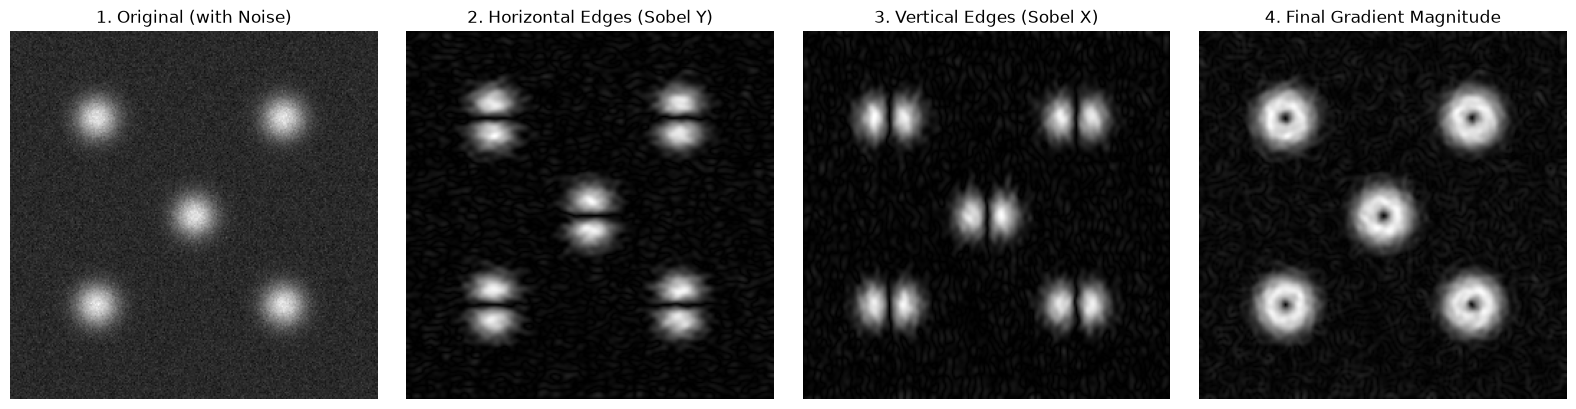

In [8]:
def grad_magnitude_sp(image):
    g = spnd.gaussian_filter(image, sigma=2)
    gx = spnd.sobel(g, axis=0)
    gy = spnd.sobel(g, axis=1)
    return np.sqrt(gx*gx + gy*gy)

def grad_magnitude(image):
    # TODO: 모듈 선택(spnd/cpnd) -> gaussian_filter(sigma=2) -> sobel(axis=0/1) -> sqrt(gx^2+gy^2)
    raise NotImplementedError
# ref=grad_magnitude(img); out=cp.asnumpy(grad_magnitude(cp.asarray(img)))
# allclose(ref,out,rtol=1e-3,atol=1e-3,name='grad_mag')
# compare('grad_magnitude', lambda: grad_magnitude(img), lambda: grad_magnitude(cp.asarray(img)), n_repeat=3, n_warmup=1)

# 시각화를 위해 추가. 중간 단계 변화를 끄집어내어 그림으로 그립니다.
import matplotlib.pyplot as plt 
g_img = spnd.gaussian_filter(img, sigma=2)
gx_img = spnd.sobel(g_img, axis=0)  # 가로 방향 경계선
gy_img = spnd.sobel(g_img, axis=1)  # 세로 방향 경계선
magnitude = np.sqrt(gx_img*gx_img + gy_img*gy_img)  # 최종 합성 테두리

# 4칸짜리 가로 모니터를 만들어 원리를 봅니다.
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title("1. Original (with Noise)")
plt.axis('off')

plt.subplot(1, 4, 2)
# 가로 변화량은 위아래 테두리가 흰색/검은색 선으로 두드러집니다.
plt.imshow(np.abs(gx_img), cmap='gray')
plt.title("2. Horizontal Edges (Sobel Y)")
plt.axis('off')

plt.subplot(1, 4, 3)
# 세로 변화량은 좌우 테두리가 흰색/검은색 선으로 두드러집니다.
plt.imshow(np.abs(gy_img), cmap='gray')
plt.title("3. Vertical Edges (Sobel X)")
plt.axis('off')

plt.subplot(1, 4, 4)
# 두 변화량을 합치면 도넛 모양의 완벽한 둥근 테두리 선이 드러납니다.
plt.imshow(magnitude, cmap='gray')
plt.title("4. Final Gradient Magnitude")
plt.axis('off')

plt.tight_layout()
plt.show()


<details><summary>💡 해답 보기</summary>

```python
def grad_magnitude(image):
    if cp.get_array_module(image) is cp:
        ndi = cpnd; xp = cp
    else:
        ndi = spnd; xp = np
    g = ndi.gaussian_filter(image, sigma=2)
    gx = ndi.sobel(g, axis=0); gy = ndi.sobel(g, axis=1)
    return xp.sqrt(gx*gx + gy*gy)
```

포인트: `cp.get_array_module(image)`로 입력이 CuPy 배열인지 검사해 `ndi`/`xp`를 자동으로 고르는
패턴은 앞선 `count_blobs`보다 한 단계 더 나아간 형태 — 호출자가 모듈을 명시하지 않아도 배열
타입만으로 CPU/GPU를 자동 판별하는, 실전 라이브러리 코드에서 흔히 쓰는 관용구입니다(`00_intro_env`
3.2절에서 언급한 `get_array_module`이 여기서 실전 예시로 다시 등장합니다).
</details>

<a id="4"></a>
## 4. 희소행렬 `sparse` (+ 포맷·내부구조)

📖 [`cupyx.scipy.sparse`](https://docs.cupy.dev/en/stable/reference/scipy_sparse.html) (cuSPARSE)

0이 아닌 값만 저장하는 2-D 포맷 네 가지를 제공합니다.

| 포맷 | 클래스 | 특징 |
|------|--------|------|
| 압축 행 | `csr_matrix` | 행 압축 — **SpMV 효율적** |
| 좌표 | `coo_matrix` | `(data,(row,col))` 구성 편리 |
| 압축 열 | `csc_matrix` | 열 압축 |
| 대각 | `dia_matrix` | 대각 위주 |

CSR은 `data`(값), `indices`(열 번호), `indptr`(행 시작 위치) 세 배열로 저장됩니다.

### 조금 더 구체적으로

포맷 선택은 **어떤 연산을 반복하느냐**에 달려 있습니다.

| 하고 싶은 것 | 권장 포맷 | 이유 |
|---|---|---|
| 행렬-벡터 곱(SpMV) 반복 | `csr_matrix` | 행 단위 순회가 캐시 친화적, cuSPARSE SpMV 커널이 CSR에 최적화 |
| 행렬 조립(요소를 하나씩 추가) | `coo_matrix` | `(row, col, val)` 삼중항을 순서 무관하게 쌓기만 하면 됨 |
| 열 단위 슬라이싱·연산 | `csc_matrix` | CSR의 행↔열을 뒤바꾼 구조 |
| 대각 행렬(예: 항등행렬 스케일링) | `dia_matrix` | 대각선 오프셋만 저장, 메모리 최소 |

실전 워크플로는 보통 "**COO로 조립 → CSR로 변환(`tocsr()`) → SpMV 반복**" 순서를 따릅니다 —
이 노트북의 4절 코드가 정확히 그 패턴입니다. 이 포맷들은 모두 **cuSPARSE**가 구동하며, cuSPARSE는
NVIDIA가 제공하는 희소행렬 전용 라이브러리로 SpMV·SpMM·희소 LU 등을 지원합니다.


### 🔬 이론 배경 — 희소행렬은 어떻게 저장되나 (CSR)
- **CSR**은 3개 배열로 저장:
  - `data`: 0이 아닌 값들(행 우선 순서)
  - `indices`: 각 값의 **열 번호**
  - `indptr`: 각 **행의 시작 오프셋**(길이 = 행수+1, 마지막 = 총 nnz)
- 행 i의 원소 = `data[indptr[i]:indptr[i+1]]`, 열 = `indices[동일 구간]`.
- 메모리는 **O(nnz)**(비영 개수)뿐 — 밀집 저장 O(n²)보다 훨씬 작고, 행 순회·SpMV에 효율적. (출처: SciPy `csr_matrix`)

### 조금 더 구체적으로 — 바로 아래 코드의 예시로 확인

아래 코드 셀은 3×3 행렬에 4개의 비영 원소(`4, 1, 3, 2`)를 COO로 넣고 CSR로 변환합니다. 이 작은
예시로 CSR 필드를 손으로 계산해보면:

- 밀집 형태: 행 0 = `[4, 0, 1]`, 행 1 = `[0, 3, 0]`, 행 2 = `[0, 0, 2]`
- `data = [4, 1, 3, 2]` (행 우선으로 값만 나열)
- `indices = [0, 2, 1, 2]` (각 값이 속한 열 번호)
- `indptr = [0, 2, 3, 4]` — 행 0은 `data[0:2]`(=4,1), 행 1은 `data[2:3]`(=3), 행 2는
  `data[3:4]`(=2)에 대응. 마지막 원소(4)가 곧 전체 비영 개수(nnz)입니다.

**메모리 절감 규모**: 5절에서 만드는 `n×n` 격자의 2D 라플라시안은 전체 자유도가 `n²`이지만, 한
행당 비영 원소는 최대 5개(자기 자신 + 상하좌우)뿐입니다. `n=60`이면 밀집 저장은 `(n²)² = n⁴ =
60⁴ ≈ 1.3×10⁷`개 원소(float32 기준 약 50 MB)가 필요하지만, CSR은 `nnz ≈ 5n² = 18,000`개 원소
(약 70 KB 남짓)면 충분합니다 — **수백 배** 차이입니다. `n`이 커질수록 밀집 저장은 `n⁴`으로
폭증하는 반면(`n×n` 격자의 미지수 수 자체가 `n²`이므로 행렬은 `n²×n²`) 희소 저장은 `O(n²)`에
그쳐, 큰 `n`에서는 밀집 저장이 아예 메모리에 들어가지 않는 지점이 금방 찾아옵니다.


In [9]:
import scipy.sparse as sps
import cupyx.scipy.sparse as cps
# COO -> CSR 내부 구조 관찰
rows=cp.array([0,0,1,2]); cols=cp.array([0,2,1,2]); vals=cp.array([4.,1.,3.,2.],dtype=cp.float32)
A = cps.coo_matrix((vals,(rows,cols)), shape=(3,3)).tocsr()
print('dense=\n', cp.asnumpy(A.toarray()))
print('data   :', cp.asnumpy(A.data))
print('indices:', cp.asnumpy(A.indices))
print('indptr :', cp.asnumpy(A.indptr))

dense=
 [[4. 0. 1.]
 [0. 3. 0.]
 [0. 0. 2.]]
data   : [4. 1. 3. 2.]
indices: [0 2 1 2]
indptr : [0 2 3 4]


In [10]:
# 2D 라플라시안을 diags+kron 으로 구성 (SciPy/CuPy 동일 코드)
def laplacian_2d(S, n):
    I = S.identity(n, format='csr', dtype='float32')
    T = S.diags([-1.,2.,-1.], [-1,0,1], shape=(n,n), format='csr', dtype='float32')
    return (S.kron(I,T) + S.kron(T,I)).tocsr()
n=60 # n을 변경해보세요
A_cpu=laplacian_2d(sps,n); A_gpu=laplacian_2d(cps,n)
x_np=np.random.random(n*n).astype(np.float32); x_cp=cp.asarray(x_np)
allclose(A_cpu@x_np, A_gpu@x_cp, rtol=1e-4, atol=1e-4, name='SpMV')
compare('SpMV', lambda:A_cpu@x_np, lambda:A_gpu@x_cp, n_repeat=20, n_warmup=3)

[allclose OK] SpMV
            SpMV | CPU     0.018 ms | GPU     0.083 ms |   0.22x


(0.0179976224899292, 0.08274000138044357, 0.21752021017228454)

<a id="5"></a>
## 5. 희소 선형대수 `sparse.linalg` + 2D 푸아송

📖 [`cupyx.scipy.sparse.linalg`](https://docs.cupy.dev/en/stable/reference/scipy_sparse_linalg.html) — `cg`, `gmres`, `spsolve`, `eigsh`, `svds`, `norm`

이 절은 4절에서 만든 **2D 라플라시안**(이산화된 푸아송 방정식 `-∇²u = f`의 계수 행렬)을 실제로
풀어봅니다. 푸아송 방정식은 정전기 포텐셜, 정상상태 열전도, 유체의 압력장 등 물리·공학 시뮬레이션
전반에서 등장하는 대표적인 편미분방정식이며, 유한차분/유한요소로 이산화하면 항상 "큰 희소행렬을
얼마나 빠르게 푸느냐"의 문제로 귀결됩니다. `cg`(반복법의 대표주자)와 `spsolve`(희소 직접법),
`eigsh`(희소 고유값)를 같은 행렬로 비교해 각각의 트레이드오프를 체감합니다.


### 🔬 이론 배경 — 직접법 vs 반복법
- **직접법**(`spsolve`, LU): 분해로 정확해를 구하지만, 큰 희소행렬은 **fill-in**으로 메모리 부담.
- **반복법**(`cg` 등): 행렬-벡터 곱(SpMV)만 반복해 근사해에 수렴. 메모리 적음.
- **CG**는 **대칭 양의 정부호(SPD)** 행렬에서 잔차를 최소화하며 수렴 — 라플라시안이 대표 예.

### 조금 더 구체적으로

- **fill-in이란**: 희소행렬을 LU 분해하면, 원래 0이었던 위치에 0이 아닌 값이 새로 생기는 현상이
  일어납니다(=fill-in). 2D 격자 문제(5-포인트 스텐실)에서는 보통 심하지 않지만, 3D 격자나
  비구조 격자에서는 fill-in이 급격히 늘어 메모리를 지배할 수 있습니다. 이것이 대규모 문제에서
  직접법 대신 반복법을 선호하는 핵심 이유입니다.
- **CG의 수렴 속도**: 켤레기울기법(Conjugate Gradient)의 반복 횟수는 대략 `O(√κ)`(κ = 행렬의
  조건수, condition number)에 비례해 필요한 정확도에 도달합니다. 라플라시안류 행렬은 격자를
  촘촘히 할수록(`n`이 커질수록) 조건수가 나빠져 CG가 느려지는데, 이를 완화하는 기법이
  **전처리(preconditioning)** 입니다(이 노트북에서는 다루지 않지만, `cg` 함수는 `M` 인자로
  전처리 행렬을 받을 수 있습니다).
- **메모리 관점**: 희소 반복법은 SpMV 한 번에 필요한 메모리가 `O(nnz)`로 고정되어 있어, 격자를
  키워도(=`n` 증가) 메모리 사용량이 완만하게 늘어납니다. 이런 메모리 사용 패턴을 실측하는 방법은
  `05_memory_profiling`에서 다룹니다.


In [11]:
from cupyx.scipy.sparse.linalg import cg, spsolve, eigsh
b = cp.random.random(n*n, dtype=cp.float32)

# 직접법(spsolve) vs 반복법(cg)
x_cg, info = cg(A_gpu, b, maxiter=2000, rtol=1e-6)
x_dir = spsolve(A_gpu.tocsr(), b)
print('cg info', info, '| cg vs spsolve 상대차:', float(cp.linalg.norm(x_cg-x_dir)/cp.linalg.norm(x_dir)))
vals = eigsh(A_gpu, k=3, which='LM', return_eigenvectors=False)
print('최대 고유값 3개:', cp.asnumpy(cp.sort(vals))[::-1])

cg info 0 | cg vs spsolve 상대차: 9.182940993923694e-05
최대 고유값 3개: [7.9946966 7.9867477 7.9867477]


**연습 — 1D 라플라시안 + CG**: `diags`로 1D 라플라시안(2,-1)을 만들고 `cg`로 푸세요.

1D 라플라시안은 한 행에 비영 원소가 최대 3개(`-1, 2, -1`)뿐인 삼중대각(tridiagonal) 행렬로,
2D 버전보다 조건수가 훨씬 좋아 CG가 빠르게 수렴합니다. `diags`는 대각선 오프셋(`-1, 0, 1`)과
값을 지정해 대각 구조를 바로 만들어주는 편의 함수입니다 — 4절에서 `kron`으로 2D 라플라시안을
조립할 때도 내부적으로 같은 `diags` 호출이 쓰였습니다.


In [12]:
def laplacian_1d(n):
    # TODO: cps.diags([-1,2,-1],[-1,0,1],shape=(n,n),format='csr',dtype='float32')
    raise NotImplementedError
# n=5000; A=laplacian_1d(n); b=cp.random.random(n,dtype=cp.float32)
# sol,info=cg(A,b,maxiter=5000,rtol=1e-5); print(info, float(cp.linalg.norm(A@sol-b)/cp.linalg.norm(b)))

<details><summary>💡 해답 보기</summary>

```python
def laplacian_1d(n):
    return cps.diags([-1.,2.,-1.],[-1,0,1],shape=(n,n),format='csr',dtype='float32')
```

포인트: `diags`에 넘긴 오프셋 리스트 `[-1, 0, 1]`은 순서대로 "주대각선 바로 아래, 주대각선,
주대각선 바로 위"를 뜻하며, 그에 대응하는 값 리스트 `[-1., 2., -1.]`이 각 대각선을 채웁니다.
`format='csr'`을 지정하지 않으면 기본 포맷(DIA 등)으로 반환될 수 있는데, 뒤에서 `cg`/`A@sol`
같은 SpMV 연산을 반복할 것이므로 처음부터 CSR로 만들어두는 것이 자연스럽습니다(4절의 포맷
선택 기준표 참고).
</details>

<a id="6"></a>
## 6. 신호처리 `signal`

📖 [`cupyx.scipy.signal`](https://docs.cupy.dev/en/stable/reference/scipy_signal.html) — `fftconvolve`, `butter`+`filtfilt`, `spectrogram`, `welch` 등

### 예제 설명
스마트폰 통화를 할 때 주변 소음을 제거하거나, 심전도(ECG) 의료 기기에서 심장 박동 신호만 깨끗하게 걸러낼 때 쓰는 "신호 처리 필터(Butterworth Lowpass Filter)"와 소리를 시각화하는 "스펙트로그램(Spectrogram)"을 다루고 있습니다.

우리가 만든 원본 데이터(sig_np)는 1초에 5번 웅웅거리는 깨끗한 소리(5*t) 위에 자글자글한 화이트 노이즈(0.4*randn)를 강제로 섞어놓은 지저분한 상태입니다.
① butter + filtfilt (저주파 통과 필터)
 - butter(4, 0.05) (버터워스 필터): 필터의 종류입니다. "주파수가 아주 낮은 녀석들만 통과시키고, 기준치보다 높은 시끄러운 고음 노이즈들은 싹 다 커트해버려!" 하는 차단벽을 설계합니다. (4는 벽의 두께/성능, 0.05는 차단할 주파수 기준점입니다.)
 - filtfilt (양방향 필터링): 신호를 앞으로 한 번, 뒤로 한 번 총 두 번 걸러줍니다. 이렇게 앞뒤로 두 번 걸러주면 신호가 밀리거나 왜곡되는 현상(위상 지연) 없이 노이즈만 아주 깔끔하게 지워집니다.

② spectrogram (소리의 시각화 주소록)
 - 오디오 이퀄라이저 화면처럼, 시간의 흐름에 따라 어떤 주파수(고음/저음) 성분이 강하게 들어있는지 지도로 그려내는 작업입니다.
 -결과물로 나온 Sxx.shape는 그 지도의 [가로(시간) x 세로(주파수)] 크기를 나타냅니다.

### 조금 더 구체적으로

- **버터워스 필터의 두 파라미터**: `butter(N, Wn)`에서 `N`(예제의 4)은 **필터 차수**로, 클수록
  통과대역과 차단대역 사이 전환이 가팔라지지만(더 "칼같이" 자름) 위상 왜곡과 수치 불안정성도
  커집니다. `Wn`(예제의 0.05)은 **정규화 차단 주파수**로, 나이퀴스트 주파수(`fs/2`)를 1로 놓았을
  때의 비율입니다 — `fs=20000`이면 나이퀴스트는 10000 Hz이므로 `Wn=0.05`는 실제 차단 주파수
  약 500 Hz를 의미합니다(신호의 핵심 성분인 5 Hz는 여유롭게 통과, 광대역 잡음의 상당 부분은 차단).
- **filtfilt가 "양방향"인 이유**: 일반 `lfilter`(단방향)는 필터 자체의 특성 때문에 신호를 약간
  뒤로 밀리게(위상 지연) 만듭니다. `filtfilt`는 정방향으로 한 번, 신호를 뒤집어 역방향으로 한 번
  걸러 위상 지연을 상쇄시킵니다(대신 계산량은 두 배). 실시간 스트리밍에는 쓸 수 없고(미래 데이터가
  필요하므로), 이미 녹음이 끝난 신호의 오프라인 처리에 적합합니다.
- **스펙트로그램 = 짧은 시간 구간별 FFT**: `spectrogram`은 신호를 겹치는 짧은 윈도우로 잘라 각
  구간마다 FFT(=STFT, Short-Time Fourier Transform)를 계산해 쌓은 것입니다. 윈도우를 길게 하면
  주파수 해상도는 좋아지지만 어느 시점에 그 주파수가 나타났는지(시간 해상도)는 흐려집니다 — 신호
  처리에서 근본적으로 마주치는 시간-주파수 해상도의 트레이드오프입니다.


/opt/conda/lib/python3.13/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


[allclose OK] butter+filtfilt
spectrogram shape: (129, 89)


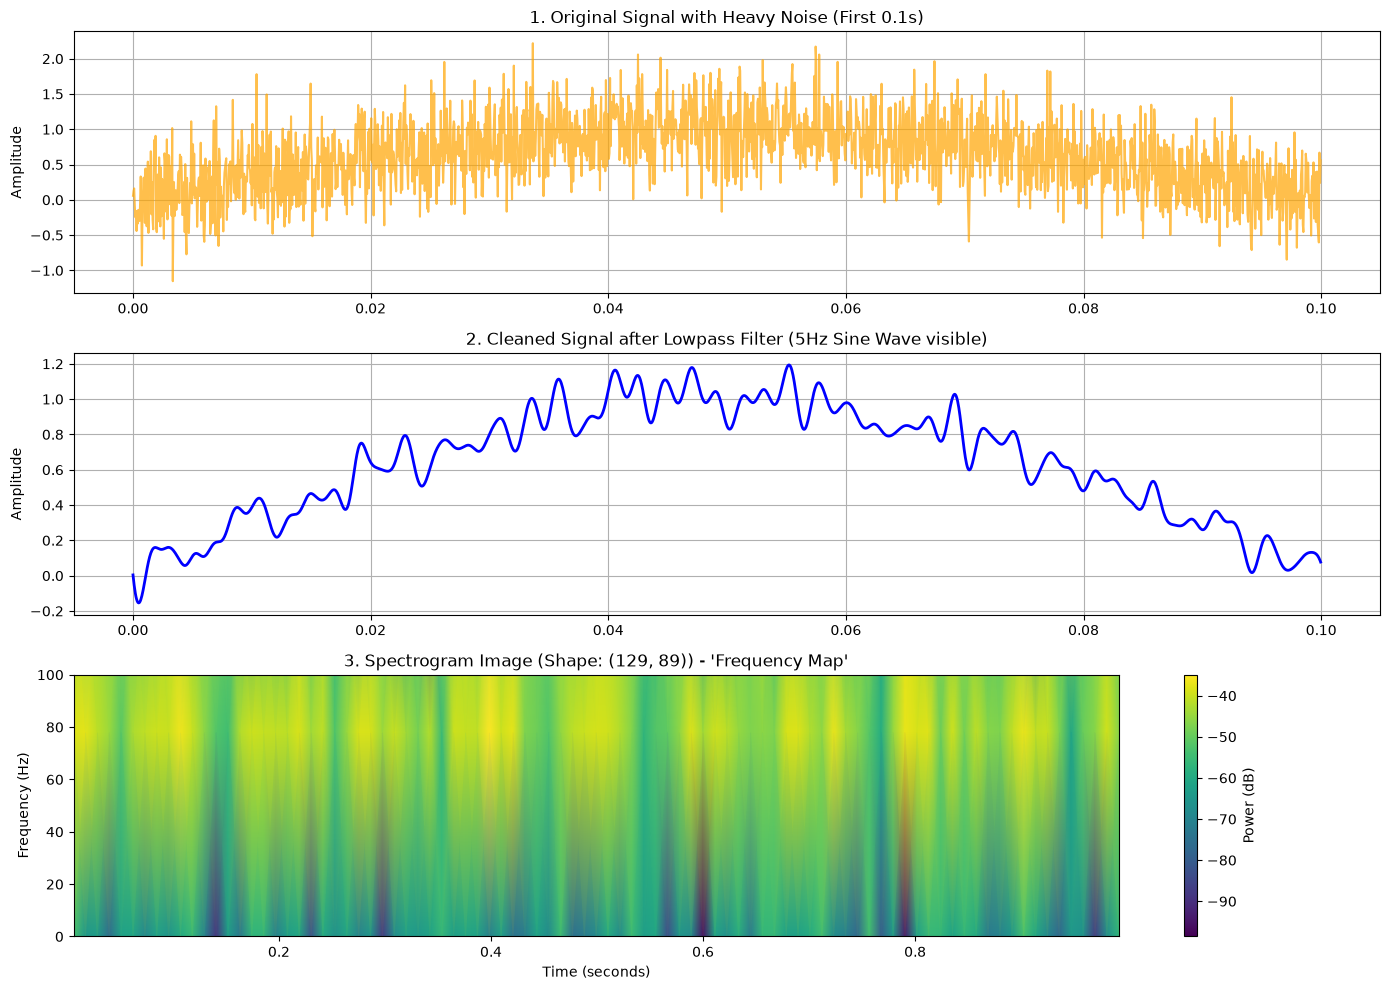

In [13]:
from scipy.signal import butter as spb, filtfilt as spf
from cupyx.scipy.signal import butter as cpb, filtfilt as cpf, spectrogram
t=np.linspace(0,1,20000,endpoint=False).astype(np.float32)
sig_np=(np.sin(2*np.pi*5*t)+0.4*np.random.randn(t.size)).astype(np.float32)
sig_cp=cp.asarray(sig_np)

def lowpass(xb,xf,sig):
    b,a=xb(4,0.05)
    return xf(b,a,sig)

allclose(lowpass(spb,spf,sig_np), cp.asnumpy(lowpass(cpb,cpf,cp.asarray(sig_np))), rtol=1e-2, atol=1e-2, name='butter+filtfilt')
compare('butter+filtfilt', lambda: lowpass(spb,spf,sig_np), lambda: lowpass(cpb,cpf,sig_cp), n_repeat=3, n_warmup=1)

# 스펙트로그램(처프)
f,tt,Sxx = spectrogram(cp.asarray(sig_np), fs=20000)
print('spectrogram shape:', Sxx.shape)

# 시각화 추가
import matplotlib.pyplot as plt 
# 중간 결과물 및 스펙트로그램 데이터를 CPU 배열로 가져옵니다.
filtered_sig = lowpass(spb, spf, sig_np)
Sxx_np = cp.asnumpy(Sxx)
f_np = cp.asnumpy(f)
tt_np = cp.asnumpy(tt)

# 시각화를 위한 그림판 준비 (3단 분할)
plt.figure(figsize=(14, 10))

# ① 첫 번째: 자글자글한 잡음이 가득한 원본 신호 파형
plt.subplot(3, 1, 1)
plt.plot(t[:2000], sig_np[:2000], color='orange', alpha=0.7)  # 앞부분 일부만 확대해서 관찰
plt.title("1. Original Signal with Heavy Noise (First 0.1s)")
plt.ylabel("Amplitude")
plt.grid(True)

# ② 두 번째: 필터를 거쳐 잡음이 사르르 녹아내린 깨끗한 파형
plt.subplot(3, 1, 2)
plt.plot(t[:2000], filtered_sig[:2000], color='blue', linewidth=2)
plt.title("2. Cleaned Signal after Lowpass Filter (5Hz Sine Wave visible)")
plt.ylabel("Amplitude")
plt.grid(True)

# ③ 세 번째: (129, 89) 구조의 소리 지도 (스펙트로그램)
plt.subplot(3, 1, 3)
# pcolormesh는 행렬 데이터를 열지도(Heatmap) 형태로 시각화해 줍니다.
plt.pcolormesh(tt_np, f_np, 10 * np.log10(Sxx_np + 1e-10), shading='gouraud', cmap='viridis')
plt.title(f"3. Spectrogram Image (Shape: {Sxx_np.shape}) - 'Frequency Map'")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (seconds)")
plt.ylim(0, 100)  # 우리가 넣은 핵심 소리가 5Hz 주변이므로 하단 영역을 확대해서 봅니다.
plt.colorbar(label="Power (dB)")

plt.tight_layout()
plt.show()

<a id="7"></a>
## 7. special · stats

📖 [`cupyx.scipy.special`](https://docs.cupy.dev/en/stable/reference/scipy_special.html) · [`cupyx.scipy.stats`](https://docs.cupy.dev/en/stable/reference/scipy_stats.html)

### 예제 설명
- expit (시그모이드 함수): 어떤 숫자가 오든 무조건 0과 1 사이의 값으로 변환해 줍니다. AI가 "이 사진이 고양이일 확률은 0.87(87%)이야"라고 확률을 답할 때 마지막 단계에서 쓰는 필수 함수입니다.
- softmax: 여러 개의 선택지(예: 개, 고양이, 호랑이)가 있을 때, 각 선택지의 점수를 "합하면 무조건 1(100%)이 되는 예쁜 확률 분포"로 정돈해 줍니다.
- zscore (표준화): 데이터들의 평균을 0, 표준편차를 1로 맞춰서 데이터의 '체급'을 똑같이 통일해 줍니다. 수능 성적표의 '표준점수'를 만드는 원리이며, AI에게 데이터를 학습시키기 전에 필수로 거치는 전처리 단계입니다.
- trim_mean (절단평균): 심사위원 점수를 매길 때 최고점과 최저점을 몇 %씩 잘라내고 남은 사람들끼리만 평균을 내는 방식입니다. 극단적인 이상치(노이즈)에 평균이 휘청거리는 것을 막아줍니다.

### 조금 더 구체적으로

- **왜 `logsumexp`가 필요한가**: softmax는 정의상 `exp(x_i) / Σ exp(x_j)`인데, `x`가 조금만
  커도(예: 수십 이상) `exp(x)`가 float32 표현 범위를 넘어 `inf`가 되고, `inf/inf = nan`이
  됩니다. `logsumexp(x) = max(x) + log(Σ exp(x - max(x)))`처럼 **최댓값을 먼저 빼고** 계산하면
  지수의 인자가 항상 0 이하가 되어 오버플로가 발생하지 않습니다 — 이것이 "수치적으로 안정한
  (stable)" softmax의 표준 구현이며, 아래 연습문제가 정확히 이 트릭을 직접 구현해보는 문제입니다.
  같은 기법이 딥러닝의 분류기 마지막 층, 어텐션(attention) 가중치 계산 등 거의 모든 softmax
  구현에 기본으로 들어갑니다.
- **`erf`(오차함수)**: 표준정규분포의 누적분포함수(CDF)와 `Φ(x) = (1 + erf(x/√2)) / 2` 관계로
  이어져 있어, 통계적 유의성 검정이나 GELU 같은 활성화 함수 구현에도 쓰입니다.
- 이 절의 함수들은 FFT·희소행렬과 달리 원소별(elementwise) 또는 간단한 리덕션 연산이 대부분이라,
  cuFFT·cuSOLVER·cuSPARSE 같은 전용 라이브러리가 아니라 CuPy 자체의 **커스텀 CUDA 커널
  (Elementwise/Reduction)** 로 구현됩니다 — Day 2에서 직접 작성하게 될 커널과 같은 종류입니다.


In [14]:
from cupyx.scipy.special import softmax as cp_softmax, logsumexp as cp_logsumexp, expit as cp_expit, erf as cp_erf
from cupyx.scipy.stats import zscore as cp_zscore, trim_mean as cp_trim_mean

from scipy.special import softmax as sp_softmax, logsumexp as sp_logsumexp, expit as sp_expit, erf as sp_erf
from scipy.stats import zscore as sp_zscore, trim_mean as sp_trim_mean

v = cp.linspace(-6,6,7,dtype=cp.float32)
print('expit:', cp.asnumpy(cp_expit(v)).round(3))
print('softmax 합:', float(cp_softmax(v).sum()))

data = cp.random.random(1_000_000, dtype=cp.float32)
print('zscore mean/std:', float(cp_zscore(data).mean()), float(cp_zscore(data).std()))
print('trim_mean(10%):', float(cp_trim_mean(data, 0.1)))

v_np = cp.asnumpy(v)
data_np = cp.asnumpy(data)

compare('expit', lambda: sp_expit(v_np), lambda: cp_expit(v), n_repeat=3, n_warmup=1)
compare('softmax', lambda: sp_softmax(v_np), lambda: cp_softmax(v), n_repeat=3, n_warmup=1)
compare('zscore', lambda: sp_zscore(data_np), lambda: cp_zscore(data), n_repeat=3, n_warmup=1)
compare('trim_mean', lambda: sp_trim_mean(data_np, 0.1), lambda: cp_trim_mean(data, 0.1), n_repeat=3, n_warmup=1)

expit: [0.002 0.018 0.119 0.5   0.881 0.982 0.998]
softmax 합: 1.0
zscore mean/std: -2.1519470294606435e-07 1.0
trim_mean(10%): 0.49989190697669983


**연습 — 수치 안정 softmax**: `logsumexp`로 직접 softmax를 구현하고 `special.softmax`와 비교하세요.

float32에서 `exp(x)`는 `x`가 대략 88을 넘어가면 오버플로(`inf`)가 나기 시작합니다. 연습문제의
`z`는 `[0, 20]` 범위로 스케일링되어 있어 이미 아슬아슬한 영역이므로, `logsumexp`를 쓰지 않고
`cp.exp(z) / cp.exp(z).sum()`처럼 그대로 구현하면 큰 값 근처에서 오차가 커지거나 `nan`이 나올 수
있음을 직접 확인할 좋은 기회입니다.


In [15]:
def my_softmax(x):
    # TODO: xp.exp(x - logsumexp(x))
    raise NotImplementedError
# z=cp.random.random(1000,dtype=cp.float32)*20
# allclose(my_softmax(z), softmax(z), rtol=1e-4, atol=1e-6, name='softmax')

<details><summary>💡 해답 보기</summary>

```python
def my_softmax(x):
    return cp.exp(x - cp_logsumexp(x))
z = cp.random.random(1000, dtype=cp.float32)*20
allclose(my_softmax(z), cp_softmax(z), rtol=1e-4, atol=1e-6, name='softmax')
```

포인트: `cp.exp(x - logsumexp(x))`는 수학적으로 `exp(x) / Σexp(x)`와 동일하지만
(`exp(x - logsumexp(x)) = exp(x) / exp(logsumexp(x)) = exp(x) / Σexp(x)`), 뺄셈을 먼저 수행해
지수의 인자를 안전한 범위로 낮춘다는 점에서 수치적으로 우월합니다. `special.softmax`도 내부적으로
정확히 이 방식(또는 동등한 안정화 기법)을 사용합니다.
</details>

<a id="8"></a>
## 8. 체크포인트

- [ ] `scipy.fft`(DCT)로 압축 데모를 했다
- [ ] `scipy.linalg`(lu_solve·expm)를 GPU에서 실행했다
- [ ] `ndimage`로 연결요소 라벨링·그래디언트를 구했다
- [ ] 희소 CSR 내부구조(data/indices/indptr)를 이해하고 SpMV했다
- [ ] `sparse.linalg`로 2D 푸아송을 직접/반복법으로 풀었다
- [ ] `signal`(butter+filtfilt·spectrogram)·`special`(안정 softmax)을 사용했다

**Day 1 단원 2 완료.** 이 노트북에서 다룬 FFT·조밀 선형대수·희소행렬·신호처리는 모두 "정확도는
유지한 채 계산만 GPU 라이브러리(cuFFT/cuSOLVER/cuSPARSE)에 위임"하는 동일한 패턴이었습니다.
다음 노트북 **`05_memory_profiling`** 에서는 이 연산들이 실제로 GPU 메모리를 얼마나 쓰는지,
전송·할당이 성능에 어떻게 영향을 주는지를 직접 프로파일링합니다.
